In [1]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np
from time import perf_counter

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


# (Introduction to linear solvers in Firedrake / PETSc)

We consider the diffusion-reaction problem

\begin{equation*}
\begin{cases}
- \Delta u + u = f & {\rm in} \ \Omega=(0,1)^2, \\
u = 0 & {\rm on} \ \partial\Omega,
\end{cases}
\end{equation*}
with $f(x,y)=(1+2\pi^2)\sin(\pi x)\sin(\pi y)$ and exact solution $u_\text{ex}(x,y)=\sin(\pi x)\sin(\pi y)$.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


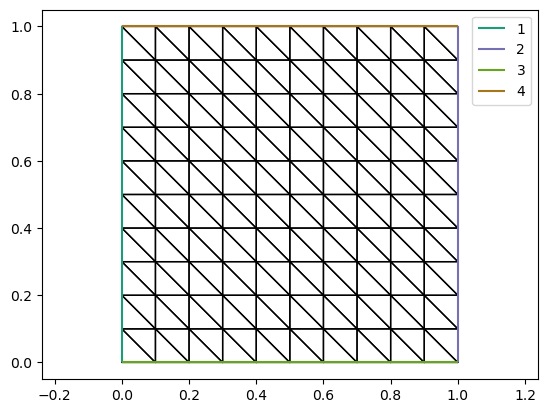

In [4]:
N = 10
# Build the mesh
mesh = UnitSquareMesh(N, N, diagonal='left')

# Plot it
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.axis('equal')

# Define a discrete function space
V = FunctionSpace(mesh, 'P', 1)

# Define trial and test functions as belonging to the space
u = TrialFunction(V)
v = TestFunction(V)

# Data
x = SpatialCoordinate(mesh)
u_ex = Function(FunctionSpace(mesh, 'P', 2))    # higher-order FE space to avoid spoiling from interpolation error
u_ex.interpolate(sin(pi*x[0])*sin(pi*x[1]))
f = (1+2*pi*pi)*sin(pi*x[0])*sin(pi*x[1])
bcs = [ DirichletBC(V, Constant(0.0), (1,2,3,4)) ]

# Define the variational problem: bilinear form and rhs
a = dot(grad(u), grad(v)) * dx + u*v*dx
L = f*v*dx

In [5]:
uh = Function(V)

# Define structures to assemble matrix and vector (does not actually perform the assembly: this is done at the first call of a solver)
vpb = LinearVariationalProblem(a, L, uh, bcs=bcs)

In [6]:
from time import perf_counter

default_solver =  LinearVariationalSolver(vpb)
# NOT NECESSARILY THE ONE REPORTED HERE:
# https://www.firedrakeproject.org/solving-interface.html#default-solver-options

parameters = {'ksp_type': 'preonly', "pc_type": "lu",
                             "pc_factor_mat_solver_type": "mumps"}
direct_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

parameters = {'ksp_type': 'gmres', 'pc_type': 'none',
              'ksp_rtol': 1.e-8, 'ksp_max_it': 10000}
gmres_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

parameters = {'ksp_type': 'cg', 'pc_type': 'none',
              'ksp_rtol': 1.e-8, 'ksp_max_it': 10000}
cg_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
default_solver.solve()
print('DEFAULT SOLVER    -   elapsed time =', perf_counter() - t0, 's    -    # iter =', default_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
direct_solver.solve()
print('DIRECT SOLVER     -   elapsed time =', perf_counter() - t0, 's    -    # iter =', direct_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
gmres_solver.solve()
print('GMRES SOLVER      -   elapsed time =', perf_counter() - t0, 's    -    # iter =', gmres_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
cg_solver.solve()
print('CG SOLVER         -   elapsed time =', perf_counter() - t0, 's    -    # iter =', cg_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

DEFAULT SOLVER    -   elapsed time = 0.08181617399986862 s    -    # iter = 1
                  -   error = 0.3472290030736745
DIRECT SOLVER     -   elapsed time = 0.004196187000161444 s    -    # iter = 1
                  -   error = 0.3472290030736745
GMRES SOLVER      -   elapsed time = 0.0047356329996546265 s    -    # iter = 15
                  -   error = 0.3472290030736744
CG SOLVER         -   elapsed time = 0.003152059000058216 s    -    # iter = 15
                  -   error = 0.3472290030736743


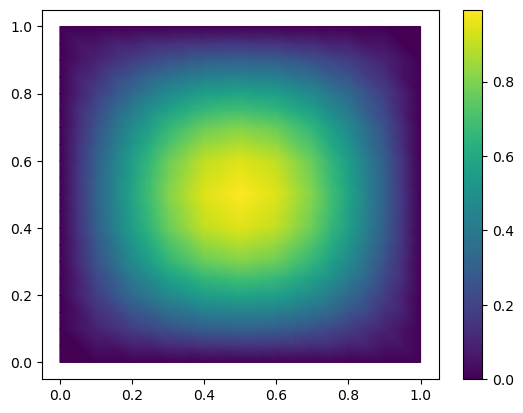

In [7]:
# Plot the numerical solution
fig, ax = plt.subplots()
q = tripcolor(uh, axes=ax)
fig.colorbar(q)

In [8]:
# check default parameters
from firedrake.petsc import DEFAULT_KSP_PARAMETERS
print('default parameters:',DEFAULT_KSP_PARAMETERS,'\n')

# from Firedrake Matrix object (output of assemble of bilinear form) to numpy array
def mat2numpy(A):
  return A.petscmat.getValues(range(0, A.petscmat.getSize()[0]), range(0,  A.petscmat.getSize()[1]))
# from Firedrake Cofunction object (output of assemble of linear form) to numpy array
def cofun2numpy(b):
  return b.dat.data

# check stop criterion
A = mat2numpy(assemble(a, bcs=bcs))
b = cofun2numpy(assemble(L, bcs=bcs))
u_array = uh.dat.data
res = b - (A @ u_array)     # numpy matrix-product operator: @
print('CG SOLUTION  -   relative residual =', np.linalg.vector_norm(res)/np.linalg.vector_norm(b))

# further details on iterative solver
parameters.update({"ksp_monitor": None, 'ksp_monitor_true_residual': None})
cg_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)
uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
cg_solver.solve()

default parameters: {'mat_type': 'aij', 'ksp_type': 'preonly', 'ksp_rtol': 1e-07, 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps', 'pc_factor_mat_mumps_icntl_14': 200} 

CG SOLUTION  -   relative residual = 6.598889659335226e-09
    Residual norms for firedrake_6_ solve.
    0 KSP Residual norm 1.020064918150e+00
    Residual norms for firedrake_6_ solve.
    0 KSP preconditioned resid norm 1.020064918150e+00 true resid norm 1.020064918150e+00 ||r(i)||/||b|| 1.000000000000e+00
    1 KSP Residual norm 3.992998196723e-02
    1 KSP preconditioned resid norm 3.992998196723e-02 true resid norm 3.992998196723e-02 ||r(i)||/||b|| 3.914454977988e-02
    2 KSP Residual norm 1.945711780191e-02
    2 KSP preconditioned resid norm 1.945711780191e-02 true resid norm 1.945711780191e-02 ||r(i)||/||b|| 1.907439169382e-02
    3 KSP Residual norm 1.253590044731e-02
    3 KSP preconditioned resid norm 1.253590044731e-02 true resid norm 1.253590044731e-02 ||r(i)||/||b|| 1.228931632121e-02
    4 KSP R

Preconditioning

In [9]:
parameters = {'ksp_type': 'gmres', 'pc_type': 'none',
              'ksp_rtol': 1.e-8, 'ksp_max_it': 10000}
gmres_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

parameters.update({'pc_type': 'ilu'})
pgmres_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
gmres_solver.solve()
print('GMRES SOLVER      -   elapsed time =', perf_counter() - t0, 's    -    # iter =', gmres_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
pgmres_solver.solve()
print('P-GMRES SOLVER    -   elapsed time =', perf_counter() - t0, 's    -    # iter =', pgmres_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

GMRES SOLVER      -   elapsed time = 0.0032564680004725233 s    -    # iter = 15
                  -   error = 0.3472290030736744
P-GMRES SOLVER    -   elapsed time = 0.0065360159996998846 s    -    # iter = 8
                  -   error = 0.3472290030736712


# Ex.1 - Stokes: GMRES and ILU preconditioning

We consider the following cavity problem

\begin{equation*}
\begin{cases}
- \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,1)^2, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_4.\\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus\Gamma_4, \\
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D} = 1\boldsymbol{i}$. We solve this problem using GMRES and ILU for preconditioning.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


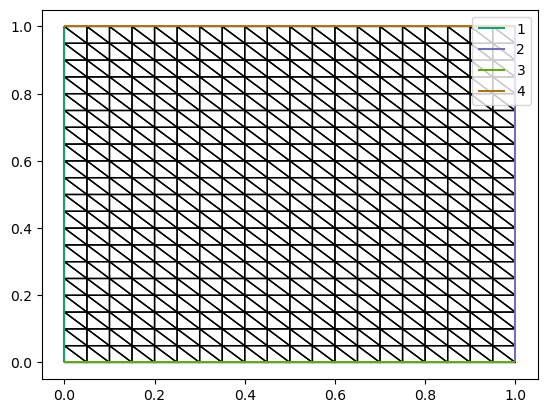

In [10]:
# Build the mesh

N = 20
mesh = UnitSquareMesh(N, N)

fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()

In [11]:
# Stokes problem

# Define function space and trial/test functions for velocity and pressure
V = VectorFunctionSpace(mesh, "P", 2)
Q = FunctionSpace(mesh, "P", 1)
W = MixedFunctionSpace([V, Q])
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
print('Number of DOF \n - u    :',V.dim(),' \n - p    :',Q.dim(),' \n - total:',W.dim(), "\n")

# Other choices of function spaces:

# P1-P0
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'DP', 0) # NB: P0 are DISCONTINUOUS elements (DP)

# # P1-P1
# V = VectorFunctionSpace(mesh, 'P', 1)
# Q = FunctionSpace(mesh, 'P', 1)

# # P1b-P1
# # The enrichment of the velocity space has to be done at the finite element level
# V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
# B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension + 1)
# V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
# V = FunctionSpace(mesh, V_el)
# Q = FunctionSpace(mesh, 'P', 1)

# Define boundary conditions for velocity (Dirichlet BCs)
bcs = [DirichletBC(W.sub(0), Constant((1.0, 0.0)), 4), # Top boundary
       DirichletBC(W.sub(0), Constant((0.0, 0.0)), (1,2,3)) # Bottom, left, right boundaries
       ]

# Define the variational problem
a = inner(grad(u), grad(v)) * dx - p * div(v) * dx + q * div(u) * dx
L = inner(Constant((0.0, 0.0)), v) * dx

# !!!!!!!!!!!
# Solve the problem passing the null space for fully Dirichlet conditions 
w_h = Function(W)
nullspace = MixedVectorSpaceBasis(W, [W.sub(0), VectorSpaceBasis(constant=True, comm=COMM_WORLD)])
variation_problem = LinearVariationalProblem(a, L, w_h, bcs=bcs)

w_h.assign(0)
direct_solver = LinearVariationalSolver(variation_problem, nullspace=nullspace)
t0 = perf_counter()
direct_solver.solve()
direct_time = perf_counter() - t0

w_h.assign(0)
parameters = {'ksp_type': 'gmres', 'pc_type': 'none', 'ksp_rtol': 1.e-8, 'ksp_max_it': 40000}
gmres_no_prec = LinearVariationalSolver(variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
gmres_no_prec.solve()
gmres_no_prec_time = perf_counter() - t0

w_h.assign(0)
parameters = {'ksp_type': 'gmres', 'pc_type': 'ilu', 'ksp_rtol': 1.e-8, 'ksp_max_it': 40000}
gmres_ilu = LinearVariationalSolver(variation_problem, solver_parameters=parameters, nullspace=nullspace)
t0 = perf_counter()
gmres_ilu.solve()
gmres_ilu_time = perf_counter() - t0

# Print the number of iterations and the final residual norm
print("Direct solver (tol = 1e-8):")
print("Iterations         :", direct_solver.snes.ksp.getIterationNumber())
print("Final residual norm:", direct_solver.snes.ksp.getResidualNorm())
print("Elapsed time       :", direct_time, "s")
print("")
print("GMRES with no preconditioner (tol = 1e-8):")
print("Iterations         :", gmres_no_prec.snes.ksp.getIterationNumber())
print("Final residual norm:", gmres_no_prec.snes.ksp.getResidualNorm())
print("Elapsed time       :", gmres_no_prec_time, "s")
print("")
print("GMRES with ILU preconditioner (tol = 1e-8):")
print("Iterations         :", gmres_ilu.snes.ksp.getIterationNumber())
print("Final residual norm:", gmres_ilu.snes.ksp.getResidualNorm())
print("Elapsed time       :", gmres_ilu_time, "s")

Number of DOF 
 - u    : 3362  
 - p    : 441  
 - total: 3803 

Direct solver (tol = 1e-8):
Iterations         : 1
Final residual norm: 0.0
Elapsed time       : 1.349106388999644 s

GMRES with no preconditioner (tol = 1e-8):
Iterations         : 36635
Final residual norm: 8.448662960327883e-08
Elapsed time       : 3.655354463000549 s

GMRES with ILU preconditioner (tol = 1e-8):
Iterations         : 120
Final residual norm: 3.62261313217204e-06
Elapsed time       : 0.051252726000711846 s


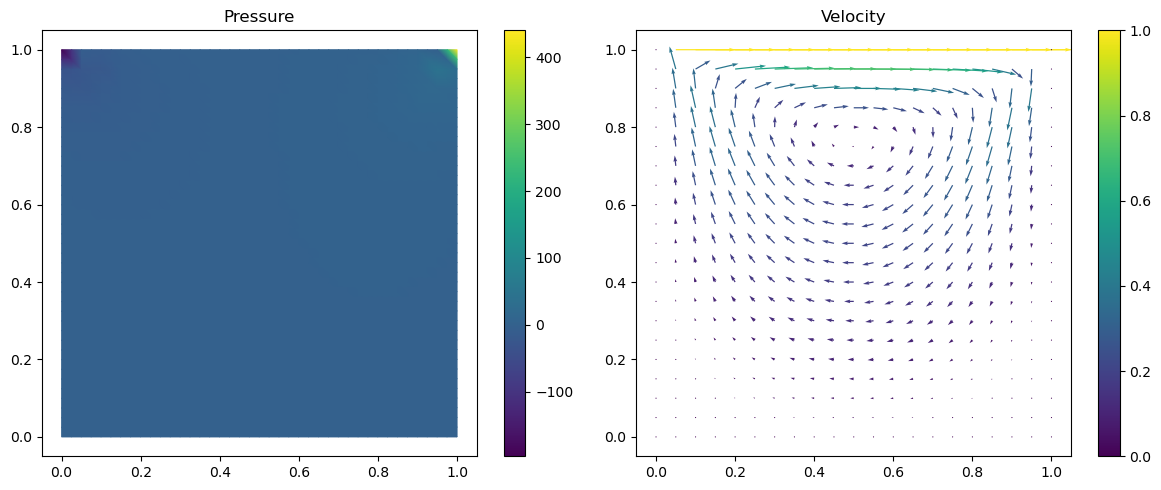

In [15]:
# Plot velocity and pressure
u_h, p_h = w_h.subfunctions


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

col0 = tripcolor(p_h, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Pressure')

col1 = quiver(u_h, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Velocity')

plt.tight_layout()


# Ex.2 - Stokes: convergence test

We want to perform a convergence test with respect to the spatial mesh. As in the previous lab, we consider the problem
\begin{equation*}
\begin{cases}
\Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{f} & {\rm in} \ \Omega=(0,1)\times(0,1), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \partial \Omega.
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D}$ such that the velocity is

$$
u(x,y)=
\begin{pmatrix}
-\cos(x)\sin(y)\\
\sin(x)\cos(y)
\end{pmatrix}
$$

and the pressure is

$$
p(x,y)
=
-\frac14\left(\cos(2x)+\cos(2y)\right)
+\frac14\sin(2).
$$

Consequentely, we also must have

$$
f=
\begin{pmatrix}
-2\cos(x)\sin(y)+\frac12\sin(2x)\\[6pt]
2\sin(x)\cos(y)+\frac12\sin(2y)
\end{pmatrix}.
$$

We recall that the null space of the resulting matrix (with Dirichlet conditions!)

$$
\Sigma = \begin{bmatrix}
A & B^T \\
B & 0
\end{bmatrix}
$$

has dimension equal to one, since translations of the pressure are allowed. We compute the null space and observe that it is one-dimensional and given by the span of

$$
\begin{bmatrix}
0 \\
1
\end{bmatrix},
$$
i.e. the space of zero velocity and constant pressure.

We start with $\mathbb{P}^2/\mathbb{P}^1$ elements.

In [16]:
def solve_stokes(n, degreeU, degreeP, gD_fun, f_fun):
    """
    Solve the Stokes problem on the unit square with fully Dirichlet boundary conditions.
    Inputs:
        n         = mesh subdivisions along each direction
        degreeU   = polynomial degree of velocity space
        degreeP   = polynomial degree of pressure space
        gD_fun    = Dirichlet data (generic function)
        f_fun     = source term (generic function)
    """
    # Mesh definition
    mesh = UnitSquareMesh(n, n, 'crossed')

    V = VectorFunctionSpace(mesh, 'P', degreeU)
    if degreeP==0:
        Q = FunctionSpace(mesh, 'DP', 0) #P0 element is discontinuous
    else:
        Q = FunctionSpace(mesh, 'P', degreeP)

    W = MixedFunctionSpace([V, Q])

    # The data generic expression are interpolated on the current mesh.
    x = SpatialCoordinate(mesh)
    gD = gD_fun(x)
    f = f_fun(x)

    bc = DirichletBC(W.sub(0), gD, (1,2,3,4))

    # Variational formulation
    u, p = TrialFunctions(W)
    v, q = TestFunctions(W)

    a = inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx
    L = inner(f, v) * dx

    # !!!!!!!!
    # Solution informing the solver of the null space for fully Dirichlet conditions
    w = Function(W)
    nullspace = MixedVectorSpaceBasis(W, [W.sub(0), VectorSpaceBasis(constant=True, comm=COMM_WORLD)])
    solve(a == L, w, bcs=bc, nullspace=nullspace)
    u, p = w.subfunctions

    return u, p, mesh

In [17]:
# Convergence test

# Define the mesh sizes and initialize error arrays
n_vec = np.array((10, 20, 40))
err_u_L2 = np.zeros(n_vec.shape[0])
err_u_H1 = np.zeros(n_vec.shape[0])
err_p_L2 = np.zeros(n_vec.shape[0])
err_p_H1 = np.zeros(n_vec.shape[0])
err_p_hat_L2 = np.zeros(n_vec.shape[0])  

# Exact solution and source term
u_ex_fun = lambda x: as_vector((
    -cos(x[0]) * sin(x[1]),
    sin(x[0]) * cos(x[1])))
p_ex_fun = lambda x: -0.25 * (cos(2*x[0]) + cos(2*x[1])) + 0.25*sin(2.0)
f_fun = lambda x: as_vector((
    -2 * cos(x[0]) * sin(x[1]) + 0.5 * sin(2 * x[0]),
    2 * sin(x[0]) * cos(x[1]) + 0.5 * sin(2 * x[1])))

for ii in range(n_vec.shape[0]):
    n = n_vec[ii]
    uh, ph, mesh = solve_stokes(n, 2, 1, u_ex_fun, f_fun)

    # Interpolate lambda functions on current mesh
    x = SpatialCoordinate(mesh)
    u_ex = u_ex_fun(x)
    p_ex = p_ex_fun(x)

    # ph_hat = ph + 1/|Ω| int (p-ph)

    ph_hat = ph + assemble((p_ex - ph) * dx) / assemble(Constant(1.0) * dx(domain=mesh))

    err_u_L2[ii] = errornorm(u_ex, uh, 'L2')
    err_u_H1[ii] = errornorm(u_ex, uh, 'H1')
    err_p_L2[ii] = errornorm(p_ex, ph, 'L2')
    err_p_hat_L2[ii] = sqrt(assemble((p_ex - ph_hat)**2 * dx))

    print('\nn = ', n_vec[ii])
    print('||u-uh||L2         = ', err_u_L2[ii])
    print('||u-uh||H1         = ', err_u_H1[ii])
    print('||p-ph||L2         = ', err_p_L2[ii])
    print('||p-ph_hat||L2     = ', err_p_hat_L2[ii])


n =  10
||u-uh||L2         =  1.6565705043060187e-05
||u-uh||H1         =  0.0012621709028414233
||p-ph||L2         =  0.0073562032102902925
||p-ph_hat||L2     =  0.00033764872769175106

n =  20
||u-uh||L2         =  2.0698663371644e-06
||u-uh||H1         =  0.00031538964988858605
||p-ph||L2         =  0.0038692256320630876
||p-ph_hat||L2     =  8.402727071046975e-05

n =  40
||u-uh||L2         =  2.58708774803134e-07
||u-uh||H1         =  7.883747762263599e-05
||p-ph||L2         =  0.0019837713665944285
||p-ph_hat||L2     =  2.0981932175977757e-05


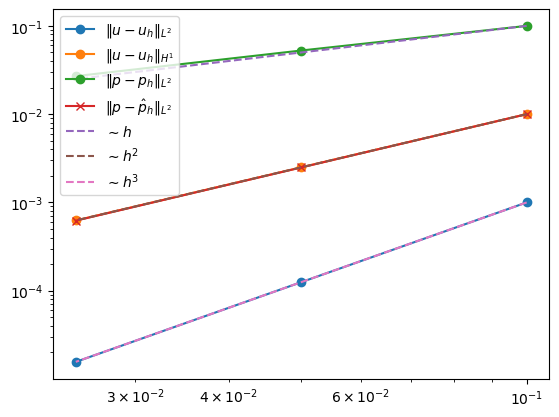

In [18]:
# Plot of error against h (log-log) keeping the same colors for right theoretical slopes
h_vec = [1.0/n for n in n_vec]
plt.loglog(h_vec, err_u_L2 * h_vec[0]**3 / err_u_L2[0], 'o-', label='$\\| u - u_h \\|_{L^2}$')
plt.loglog(h_vec, err_u_H1 * h_vec[0]**2 / err_u_H1[0], 'o-', label='$\\| u - u_h \\|_{H^1}$')
plt.loglog(h_vec, err_p_L2 * h_vec[0] / err_p_L2[0], 'o-', label='$\\| p - p_h \\|_{L^2}$')
plt.loglog(h_vec, err_p_hat_L2 * h_vec[0]**2 / err_p_hat_L2[0], 'x-', label='$\\| p - \\hat{p}_h \\|_{L^2}$')
plt.loglog(h_vec, [h for h in h_vec], '--', label='$\\sim h$')
plt.loglog(h_vec, [h**2 for h in h_vec], '--', label='$\\sim h^2$')
plt.loglog(h_vec, [h**3 for h in h_vec], '--', label='$\\sim h^3$')
plt.legend()

In [19]:
h_vec = 1.0 / n_vec

print("\nObserved convergence rates")
print("-"*30)
print("\nVelocity L2:")
for i in range(len(n_vec) - 1):
    rate = np.log(err_u_L2[i] / err_u_L2[i+1]) / np.log(2)
    print(f"between n={n_vec[i]} and n={n_vec[i+1]}: {rate:.3f}")
print("\nVelocity H1:")
for i in range(len(n_vec) - 1):
    rate = np.log(err_u_H1[i] / err_u_H1[i+1]) / np.log(2)
    print(f"between n={n_vec[i]} and n={n_vec[i+1]}: {rate:.3f}")
print("\nPressure L2:")
for i in range(len(n_vec) - 1):
    rate = np.log(err_p_L2[i] / err_p_L2[i+1]) / np.log(2)
    print(f"between n={n_vec[i]} and n={n_vec[i+1]}: {rate:.3f}")
print("\nCorrected pressure L2:")
for i in range(len(n_vec) - 1):
    rate = np.log(err_p_hat_L2[i] / err_p_hat_L2[i+1]) / np.log(2)
    print(f"between n={n_vec[i]} and n={n_vec[i+1]}: {rate:.3f}")


Observed convergence rates
------------------------------

Velocity L2:
between n=10 and n=20: 3.001
between n=20 and n=40: 3.000

Velocity H1:
between n=10 and n=20: 2.001
between n=20 and n=40: 2.000

Pressure L2:
between n=10 and n=20: 0.927
between n=20 and n=40: 0.964

Corrected pressure L2:
between n=10 and n=20: 2.007
between n=20 and n=40: 2.002


Now we do the same with $\mathbb{P}^1_b/\mathbb{P}^1$ elements.

In [20]:
def solve_stokes_bubble(n, gD_fun, f_fun):
    """
    Solve the Stokes problem on the unit square with fully Dirichlet boundary conditions.
    Inputs:
        n         = mesh subdivisions along each direction
        degreeU   = polynomial degree of velocity space
        degreeP   = polynomial degree of pressure space
        gD_fun    = Dirichlet data (generic function)
        f_fun     = source term (generic function)
    """
    # Mesh definition
    mesh = UnitSquareMesh(n, n, 'crossed')

    V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
    B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension + 1)
    V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
    V = FunctionSpace(mesh, V_el)
    Q = FunctionSpace(mesh, 'P', 1)

    W = MixedFunctionSpace([V, Q])

    # The data generic expression are interpolated on the current mesh.
    x = SpatialCoordinate(mesh)
    gD = gD_fun(x)
    f = f_fun(x)

    bc = DirichletBC(W.sub(0), gD, (1,2,3,4))

    # Variational formulation
    u, p = TrialFunctions(W)
    v, q = TestFunctions(W)

    a = inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx
    L = inner(f, v) * dx

    # !!!!!!!!
    # Solution informing the solver of the null space for fully Dirichlet conditions
    w = Function(W)
    nullspace = MixedVectorSpaceBasis(W, [W.sub(0), VectorSpaceBasis(constant=True, comm=COMM_WORLD)])
    solve(a == L, w, bcs=bc, nullspace=nullspace)
    u, p = w.subfunctions

    return u, p, mesh

In [21]:
# Convergence test

# Define the mesh sizes and initialize error arrays
n_vec = np.array((10, 20, 40))
err_u_L2 = np.zeros(n_vec.shape[0])
err_u_H1 = np.zeros(n_vec.shape[0])
err_p_L2 = np.zeros(n_vec.shape[0])
err_p_H1 = np.zeros(n_vec.shape[0])
err_p_hat_L2 = np.zeros(n_vec.shape[0])  

# Exact solution and source term
u_ex_fun = lambda x: as_vector((
    -cos(x[0]) * sin(x[1]),
    sin(x[0]) * cos(x[1])))
p_ex_fun = lambda x: -0.25 * (cos(2*x[0]) + cos(2*x[1])) + 0.25*sin(2.0)
f_fun = lambda x: as_vector((
    -2 * cos(x[0]) * sin(x[1]) + 0.5 * sin(2 * x[0]),
    2 * sin(x[0]) * cos(x[1]) + 0.5 * sin(2 * x[1])))

for ii in range(n_vec.shape[0]):
    n = n_vec[ii]
    uh, ph, mesh = solve_stokes_bubble(n, u_ex_fun, f_fun)

    # Interpolate lambda functions on current mesh
    x = SpatialCoordinate(mesh)
    u_ex = u_ex_fun(x)
    p_ex = p_ex_fun(x)

    # ph_hat = ph + 1/|Ω| int (p-ph)

    ph_hat = ph + assemble((p_ex - ph) * dx) / assemble(Constant(1.0) * dx(domain=mesh))

    err_u_L2[ii] = errornorm(u_ex, uh, 'L2')
    err_u_H1[ii] = errornorm(u_ex, uh, 'H1')
    err_p_L2[ii] = errornorm(p_ex, ph, 'L2')
    err_p_hat_L2[ii] = sqrt(assemble((p_ex - ph_hat)**2 * dx))

    print('\nn = ', n_vec[ii])
    print('||u-uh||L2         = ', err_u_L2[ii])
    print('||u-uh||H1         = ', err_u_H1[ii])
    print('||p-ph||L2         = ', err_p_L2[ii])
    print('||p-ph_hat||L2     = ', err_p_hat_L2[ii])


n =  10
||u-uh||L2         =  0.0007380255616838323
||u-uh||H1         =  0.03170475657685719
||p-ph||L2         =  0.017241507194123044
||p-ph_hat||L2     =  0.015593589163061205

n =  20
||u-uh||L2         =  0.00018290762013481874
||u-uh||H1         =  0.01563266679001069
||p-ph||L2         =  0.006556005150245366
||p-ph_hat||L2     =  0.005292774232071084

n =  40
||u-uh||L2         =  4.5615850035562165e-05
||u-uh||H1         =  0.007760360777862768
||p-ph||L2         =  0.0027208975734509546
||p-ph_hat||L2     =  0.0018623226115746395


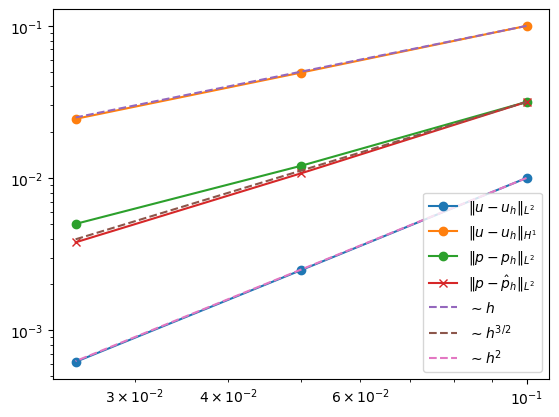

In [22]:
# Plot of error against h (log-log) keeping the same colors for right theoretical slopes
h_vec = [1.0/n for n in n_vec]
plt.loglog(h_vec, err_u_L2 * h_vec[0]**2 / err_u_L2[0], 'o-', label='$\\| u - u_h \\|_{L^2}$')
plt.loglog(h_vec, err_u_H1 * h_vec[0] / err_u_H1[0], 'o-', label='$\\| u - u_h \\|_{H^1}$')
plt.loglog(h_vec, err_p_L2 * h_vec[0]**1.5 / err_p_L2[0], 'o-', label='$\\| p - p_h \\|_{L^2}$')
plt.loglog(h_vec, err_p_hat_L2 * h_vec[0]**1.5 / err_p_hat_L2[0], 'x-', label='$\\| p - \\hat{p}_h \\|_{L^2}$')
plt.loglog(h_vec, [h for h in h_vec], '--', label='$\\sim h$')
plt.loglog(h_vec, [h**1.5 for h in h_vec], '--', label='$\\sim h^{3/2}$')
plt.loglog(h_vec, [h**2 for h in h_vec], '--', label='$\\sim h^2$')
plt.legend()

In [23]:
h_vec = 1.0 / n_vec

print("\nObserved convergence rates")
print("-"*30)
print("\nVelocity L2:")
for i in range(len(n_vec) - 1):
    rate = np.log(err_u_L2[i] / err_u_L2[i+1]) / np.log(2)
    print(f"between n={n_vec[i]} and n={n_vec[i+1]}: {rate:.3f}")
print("\nVelocity H1:")
for i in range(len(n_vec) - 1):
    rate = np.log(err_u_H1[i] / err_u_H1[i+1]) / np.log(2)
    print(f"between n={n_vec[i]} and n={n_vec[i+1]}: {rate:.3f}")
print("\nPressure L2:")
for i in range(len(n_vec) - 1):
    rate = np.log(err_p_L2[i] / err_p_L2[i+1]) / np.log(2)
    print(f"between n={n_vec[i]} and n={n_vec[i+1]}: {rate:.3f}")
print("\nCorrected pressure L2:")
for i in range(len(n_vec) - 1):
    rate = np.log(err_p_hat_L2[i] / err_p_hat_L2[i+1]) / np.log(2)
    print(f"between n={n_vec[i]} and n={n_vec[i+1]}: {rate:.3f}")


Observed convergence rates
------------------------------

Velocity L2:
between n=10 and n=20: 2.013
between n=20 and n=40: 2.004

Velocity H1:
between n=10 and n=20: 1.020
between n=20 and n=40: 1.010

Pressure L2:
between n=10 and n=20: 1.395
between n=20 and n=40: 1.269

Corrected pressure L2:
between n=10 and n=20: 1.559
between n=20 and n=40: 1.507
